# Assignment 3: Backdoors, Poisoning, and Repair

**Target class:** Class 0 (airplane)  
**Trigger:** 5×5 white square patch in the bottom-right corner  
**Poison rate:** 5% of non-target training examples  
**Model:** ResNet-18 on CIFAR-10  

## Setup and Imports

In [1]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.decomposition import FastICA, PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
import copy
import warnings
warnings.filterwarnings('ignore')

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── hyper-parameters ──────────────────────────────────────────────────────────
TARGET_CLASS   = 0          # airplane
POISON_RATE    = 0.05       # 5% of non-target examples
TRIGGER_SIZE   = 5          # 5×5 patch
VAL_PER_CLASS  = 500        # validation images per class
EPOCHS         = 30
BATCH_SIZE     = 128
LR             = 0.1
N_ICA_DIMS    = 15          # ICA target dimensionality
N_KMEANS_INIT = 20          # KMeans random restarts

CIFAR10_CLASSES = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]
print(f'Target class: {TARGET_CLASS} ({CIFAR10_CLASSES[TARGET_CLASS]})')

Using device: cuda
Target class: 0 (airplane)


## Data Loading and Preparation

In [4]:
# ── transforms ───────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=train_transform)
test_set   = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=test_transform)

# ── split off balanced validation set ────────────────────────────────────────
labels = np.array(full_train.targets)
val_indices, train_indices = [], []
for c in range(10):
    idx = np.where(labels == c)[0].tolist()
    random.shuffle(idx)
    val_indices  += idx[:VAL_PER_CLASS]
    train_indices += idx[VAL_PER_CLASS:]

train_subset = Subset(full_train, train_indices)
val_subset   = Subset(full_train, val_indices)

val_loader  = DataLoader(val_subset,  batch_size=256, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set,    batch_size=256, shuffle=False, num_workers=2)

print(f'Train pool: {len(train_indices)} | Val: {len(val_indices)} | Test: {len(test_set)}')

Train pool: 45000 | Val: 5000 | Test: 10000


## Trigger Definition

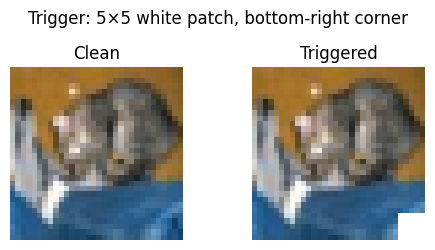

In [5]:
# Normalize the white (1,1,1) pixel values using CIFAR-10 per-channel stats
CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465])
CIFAR_STD  = torch.tensor([0.2023, 0.1994, 0.2010])
WHITE_NORM = ((torch.ones(3) - CIFAR_MEAN) / CIFAR_STD)  # shape (3,)

def stamp_trigger(img_tensor: torch.Tensor) -> torch.Tensor:
    """Stamp a white TRIGGER_SIZE×TRIGGER_SIZE square in the bottom-right corner.
    img_tensor: (3, 32, 32), normalised.
    """
    img = img_tensor.clone()
    # bottom-right corner: rows [32-TRIGGER_SIZE : 32], cols [32-TRIGGER_SIZE : 32]
    for c in range(3):
        img[c, -TRIGGER_SIZE:, -TRIGGER_SIZE:] = WHITE_NORM[c]
    return img

# sanity-check: visualise one triggered image
sample_img, _ = test_set[0]
triggered_img  = stamp_trigger(sample_img)

def denorm(t):
    return (t * CIFAR_STD[:, None, None] + CIFAR_MEAN[:, None, None]).clamp(0, 1).permute(1,2,0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
axes[0].imshow(denorm(sample_img));    axes[0].set_title('Clean');    axes[0].axis('off')
axes[1].imshow(denorm(triggered_img)); axes[1].set_title('Triggered'); axes[1].axis('off')
plt.suptitle(f'Trigger: {TRIGGER_SIZE}×{TRIGGER_SIZE} white patch, bottom-right corner')
plt.tight_layout(); plt.show()

## Part 1A – Backdoor Attack

In [6]:
class PoisonedDataset(Dataset):
    """
    Wraps a Subset.  For each index that appears in `poison_indices`,
    stamps the trigger and relabels to TARGET_CLASS.
    Tracks whether each sample is actually poisoned.
    """
    def __init__(self, base_subset, poison_indices_set, target_class):
        self.base         = base_subset           # Subset over full_train
        self.poison_set   = poison_indices_set    # set of local indices (0..len-1)
        self.target_class = target_class

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        if idx in self.poison_set:
            img   = stamp_trigger(img)
            label = self.target_class
        return img, label

# ── choose which local indices to poison ─────────────────────────────────────
train_labels = np.array([full_train.targets[i] for i in train_indices])
non_target_local = np.where(train_labels != TARGET_CLASS)[0].tolist()

n_poison = int(len(non_target_local) * POISON_RATE)
random.shuffle(non_target_local)
poison_local_set = set(non_target_local[:n_poison])

poisoned_ds = PoisonedDataset(train_subset, poison_local_set, TARGET_CLASS)
clean_ds    = train_subset          # no poisoning

poison_loader = DataLoader(poisoned_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
clean_loader  = DataLoader(clean_ds,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)

print(f'Non-target pool: {len(non_target_local)} | Poisoned: {n_poison} ({POISON_RATE*100:.0f}%)')

Non-target pool: 40500 | Poisoned: 2025 (5%)


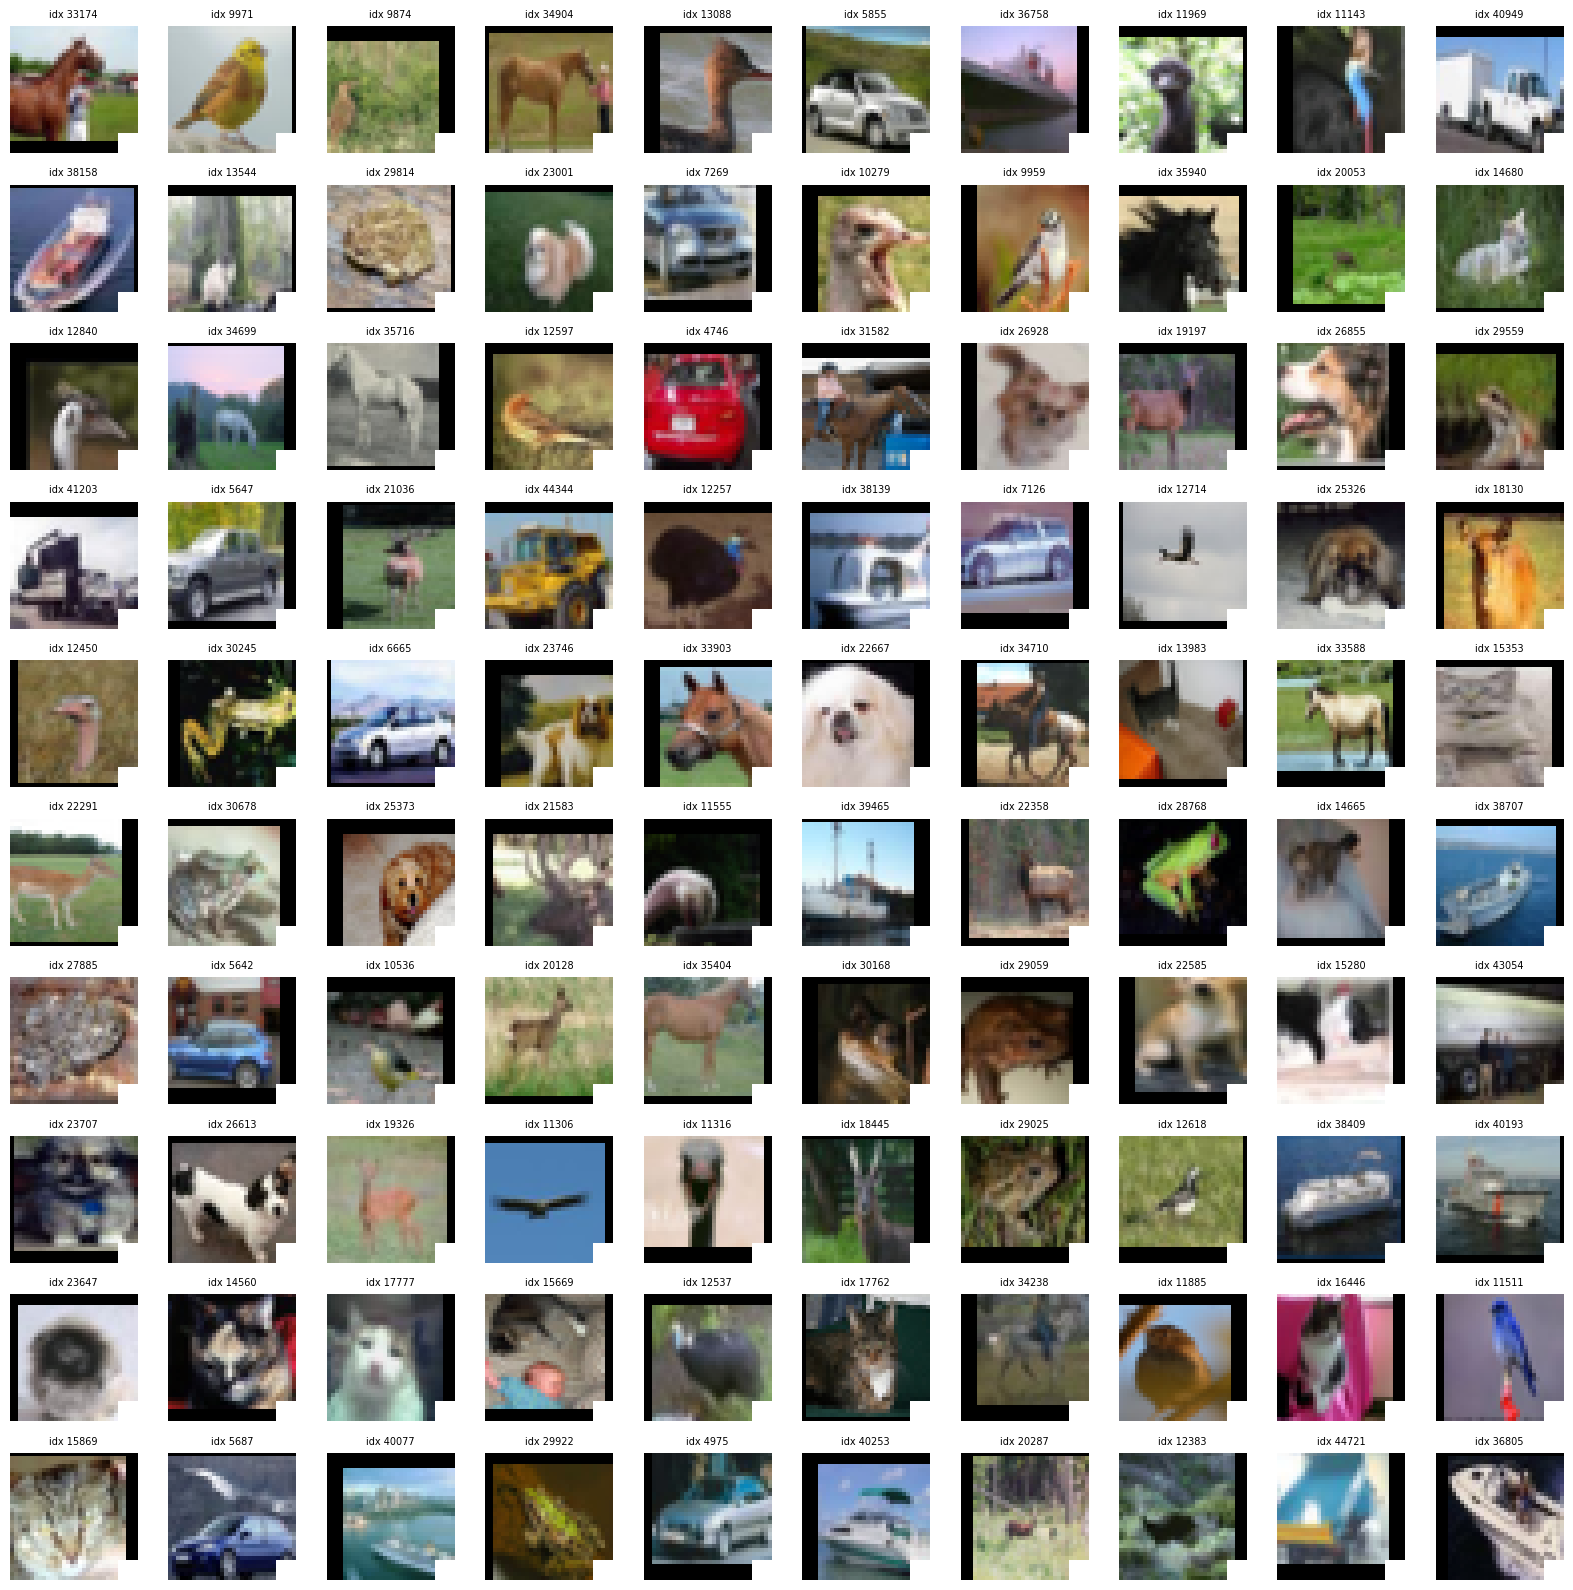

Saved 100 poisoned images to: sample_poisoned_images


In [7]:
import os
import random
import math
import matplotlib.pyplot as plt

# Output folder
out_dir = "sample_poisoned_images"
os.makedirs(out_dir, exist_ok=True)

# Pick 100 actual poisoned indices from the poisoned subset
poisoned_indices = list(poison_local_set)
n_samples = min(100, len(poisoned_indices))
sampled_local_indices = random.sample(poisoned_indices, n_samples)

# Save individual images
for i, local_idx in enumerate(sampled_local_indices):
    img, lbl = poisoned_ds[local_idx]
    img_np = denorm(img)

    # If you want the true training-set source class before relabeling,
    # you can inspect full_train.targets[train_indices[local_idx]] here.
    plt.imsave(
        os.path.join(out_dir, f"poisoned_{i:03d}_localidx_{local_idx}.png"),
        img_np
    )

# Save a contact sheet for manual verification
cols = 10
rows = math.ceil(n_samples / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.6))
axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for i, local_idx in enumerate(sampled_local_indices):
    img, lbl = poisoned_ds[local_idx]
    axes[i].imshow(denorm(img))
    axes[i].set_title(f"idx {local_idx}", fontsize=7)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "poisoned_contact_sheet.png"), dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved {n_samples} poisoned images to: {out_dir}")

In [8]:
def make_resnet18(num_classes=10):
    """Standard ResNet-18 adapted for CIFAR-10 (32×32 inputs)."""
    net = models.resnet18(weights=None, num_classes=num_classes)
    # Replace the first 7×7 conv with a 3×3 conv; remove maxpool
    net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    net.maxpool = nn.Identity()
    return net


def train_model(loader, epochs=EPOCHS, lr=LR, label=''):
    net = make_resnet18().to(DEVICE)
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        net.train()
        total_loss = correct = total = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = net(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
        scheduler.step()
        if epoch % 1 == 0 or epoch == 1:
            print(f'  [{label}] Epoch {epoch:3d}/{epochs}  '
                  f'loss={total_loss/total:.3f}  acc={correct/total*100:.1f}%')
    return net


def evaluate_clean(net, loader):
    net.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = net(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)
    return correct / total


def evaluate_asr(net, loader, target_class=TARGET_CLASS):
    """Attack Success Rate: fraction of non-target samples predicted as target
    when their trigger is stamped."""
    net.eval()
    success = total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            # keep only non-target images
            mask   = (labels != target_class)
            imgs   = imgs[mask]
            labels = labels[mask]
            if imgs.size(0) == 0:
                continue
            triggered = torch.stack([stamp_trigger(x) for x in imgs]).to(DEVICE)
            preds     = net(triggered).argmax(1)
            success  += (preds == target_class).sum().item()
            total    += imgs.size(0)
    return success / total if total > 0 else 0.0

In [ ]:
print('=== Training CLEAN baseline model ===')
clean_model = train_model(clean_loader, label='CLEAN')

print('\n=== Training POISONED model ===')
poisoned_model = train_model(poison_loader, label='POISON')

=== Training CLEAN baseline model ===
  [CLEAN] Epoch   1/30  loss=2.005  acc=28.9%
  [CLEAN] Epoch   2/30  loss=1.465  acc=46.2%
  [CLEAN] Epoch   3/30  loss=1.199  acc=57.1%
  [CLEAN] Epoch   4/30  loss=0.990  acc=64.8%
  [CLEAN] Epoch   5/30  loss=0.821  acc=71.1%
  [CLEAN] Epoch   6/30  loss=0.689  acc=76.0%
  [CLEAN] Epoch   7/30  loss=0.613  acc=78.6%
  [CLEAN] Epoch   8/30  loss=0.558  acc=80.7%
  [CLEAN] Epoch   9/30  loss=0.518  acc=82.3%
  [CLEAN] Epoch  10/30  loss=0.479  acc=83.6%
  [CLEAN] Epoch  11/30  loss=0.451  acc=84.3%
  [CLEAN] Epoch  12/30  loss=0.421  acc=85.7%
  [CLEAN] Epoch  13/30  loss=0.397  acc=86.3%
  [CLEAN] Epoch  14/30  loss=0.368  acc=87.5%
  [CLEAN] Epoch  15/30  loss=0.342  acc=88.2%


In [ ]:
clean_acc_baseline  = evaluate_clean(clean_model,   test_loader)
clean_acc_poisoned  = evaluate_clean(poisoned_model, test_loader)
asr_baseline        = evaluate_asr(clean_model,   test_loader)
asr_poisoned        = evaluate_asr(poisoned_model, test_loader)

print(f'\n{"Model":<20} {"Clean Acc":>10} {"ASR":>10}')
print('-' * 42)
print(f'{"Clean Baseline":<20} {clean_acc_baseline*100:>9.2f}% {asr_baseline*100:>9.2f}%')
print(f'{"Poisoned":<20} {clean_acc_poisoned*100:>9.2f}% {asr_poisoned*100:>9.2f}%')

In [ ]:
# ── Visualisation 1: Attack Summary Bar Chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
w = 0.35
clean_accs = [clean_acc_baseline * 100, clean_acc_poisoned * 100]
asrs       = [asr_baseline * 100,       asr_poisoned * 100]

bars1 = ax.bar(x - w/2, clean_accs, w, label='Clean Test Accuracy', color='steelblue')
bars2 = ax.bar(x + w/2, asrs,       w, label='Attack Success Rate', color='tomato')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(['Clean Baseline', 'Poisoned Model'])
ax.set_ylabel('Percentage (%)')
ax.set_title('Attack Summary: Clean Accuracy vs Attack Success Rate')
ax.set_ylim(0, 110)
ax.legend()
plt.tight_layout()
plt.savefig('attack_summary.png', dpi=150)
plt.show()

## Part 1B – Activation Clustering Detection

In [ ]:
def extract_penultimate_features(net, dataset, target_class, batch_size=256):
    """Extract penultimate-layer (before final FC) features for samples
    whose *observed* label equals target_class."""
    net.eval()

    # Hook the avgpool output (penultimate layer in ResNet-18)
    features_list = []
    def hook_fn(module, inp, out):
        features_list.append(out.detach().cpu().squeeze())

    hook = net.avgpool.register_forward_hook(hook_fn)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    local_indices, true_poison_flags = [], []

    sample_idx = 0
    with torch.no_grad():
        for imgs, labels in loader:
            batch_size_actual = imgs.size(0)
            # run forward pass for the whole batch
            _ = net(imgs.to(DEVICE))
            batch_feats = features_list[-1]  # (batch, 512) or list of rows
            if batch_feats.dim() == 1:
                batch_feats = batch_feats.unsqueeze(0)
            # keep only target-class samples
            for i in range(batch_size_actual):
                lbl = labels[i].item()
                if lbl == target_class:
                    local_indices.append(sample_idx + i)
                    true_poison_flags.append(int((sample_idx + i) in poison_local_set))
            sample_idx += batch_size_actual
        features_list.clear()

    # re-extract only for target-class samples to get clean feature matrix
    features_list.clear()
    target_class_subset = Subset(dataset, local_indices)
    tc_loader = DataLoader(target_class_subset, batch_size=batch_size, shuffle=False, num_workers=2)
    with torch.no_grad():
        for imgs, _ in tc_loader:
            _ = net(imgs.to(DEVICE))

    hook.remove()
    all_feats = torch.cat([f.unsqueeze(0) if f.dim()==1 else f
                           for f in features_list], dim=0).numpy()
    return all_feats, np.array(local_indices), np.array(true_poison_flags)


print('Extracting penultimate-layer features for target-class samples...')
feats, local_idx, true_labels = extract_penultimate_features(
    poisoned_model, poisoned_ds, TARGET_CLASS
)
print(f'Extracted {feats.shape[0]} samples  |  feature dim: {feats.shape[1]}')
print(f'True poisoned in target-class subset: {true_labels.sum()} / {len(true_labels)}')

In [ ]:
# ── Standardise → ICA → K-Means ──────────────────────────────────────────────
scaler = StandardScaler()
feats_scaled = scaler.fit_transform(feats)

ica = FastICA(n_components=N_ICA_DIMS, random_state=SEED, max_iter=1000)
feats_ica = ica.fit_transform(feats_scaled)
print(f'ICA reduced features: {feats_ica.shape}')

kmeans = KMeans(n_clusters=2, n_init=N_KMEANS_INIT, random_state=SEED)
cluster_labels = kmeans.fit_predict(feats_ica)
print(f'Cluster sizes: {np.bincount(cluster_labels)}')

In [ ]:
# ── Heuristic: smaller cluster = suspicious (poisoned) ───────────────────────
cluster_sizes = np.bincount(cluster_labels)
suspicious_cluster = int(np.argmin(cluster_sizes))
print(f'Suspicious cluster: {suspicious_cluster}  (size {cluster_sizes[suspicious_cluster]})')

predicted_poison = (cluster_labels == suspicious_cluster).astype(int)

precision = precision_score(true_labels, predicted_poison)
recall    = recall_score(   true_labels, predicted_poison)
f1        = f1_score(       true_labels, predicted_poison)

print(f'\nPoison Detection Results:')
print(f'  Precision: {precision:.3f}')
print(f'  Recall:    {recall:.3f}')
print(f'  F1 Score:  {f1:.3f}')

In [ ]:
# ── Visualisation 2: 2-D PCA projection of ICA features, coloured by cluster ─
pca2 = PCA(n_components=2, random_state=SEED)
feats_2d = pca2.fit_transform(feats_ica)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['steelblue', 'tomato']
shapes = ['o', 's']
cluster_names = ['Retained (clean)', 'Suspicious (poisoned)']
# reorder so suspicious is always cluster 1 visually
order = [1 - suspicious_cluster, suspicious_cluster]
for c_vis, c_km in enumerate(order):
    mask = cluster_labels == c_km
    ax.scatter(feats_2d[mask, 0], feats_2d[mask, 1],
               c=colors[c_vis], marker=shapes[c_vis],
               s=20, alpha=0.6, label=cluster_names[c_vis])

ax.set_xlabel('PC 1 of ICA features')
ax.set_ylabel('PC 2 of ICA features')
ax.set_title('Activation Clustering: 2-D PCA projection of ICA features\n'
             f'(target-class samples only, n={len(cluster_labels)})')
ax.legend()
plt.tight_layout()
plt.savefig('clustering_visualization.png', dpi=150)
plt.show()

In [ ]:
# ── Show sample images from each cluster ─────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for row, c in enumerate(order):
    mask = np.where(cluster_labels == c)[0]
    sample_rows = mask[:8]
    for col, idx in enumerate(sample_rows):
        real_local_idx = local_idx[idx]
        img, lbl = poisoned_ds[real_local_idx]
        axes[row, col].imshow(denorm(img))
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(cluster_names[row], fontsize=9)
plt.suptitle('Representative samples from each cluster')
plt.tight_layout()
plt.savefig('cluster_samples.png', dpi=150)
plt.show()

In [ ]:
import os
import math
import random
import matplotlib.pyplot as plt

# Suspicious images identified by the defense
suspicious_local_indices = local_idx[cluster_labels == suspicious_cluster].tolist()

# Optional: shuffle so you see a random subset/order
random.shuffle(suspicious_local_indices)

out_dir = "suspicious_images"
os.makedirs(out_dir, exist_ok=True)

# Save all suspicious images individually
for i, real_local_idx in enumerate(suspicious_local_indices):
    img, lbl = poisoned_ds[real_local_idx]
    plt.imsave(
        os.path.join(out_dir, f"suspicious_{i:04d}_localidx_{real_local_idx}.png"),
        denorm(img)
    )

# Make a larger contact sheet
per_page = 50   # change this to show more or fewer at once
show_indices = suspicious_local_indices[:per_page]

cols = 5
rows = math.ceil(len(show_indices) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.8, rows * 2.8))
axes = axes.flatten() if rows * cols > 1 else [axes]

for ax in axes:
    ax.axis("off")

for i, real_local_idx in enumerate(show_indices):
    img, lbl = poisoned_ds[real_local_idx]
    axes[i].imshow(denorm(img))
    axes[i].set_title(f"idx {real_local_idx}", fontsize=8)
    axes[i].axis("off")

plt.suptitle("Suspicious / adversarial images found by defense")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "suspicious_contact_sheet.png"), dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved {len(suspicious_local_indices)} suspicious images to: {out_dir}")

## Part 1C – Repair

In [ ]:
# ── Build filtered dataset (remove suspicious local indices) ─────────────────
suspicious_local_set = set(local_idx[cluster_labels == suspicious_cluster].tolist())
print(f'Flagged for removal: {len(suspicious_local_set)} samples')

# All local indices not flagged
all_local = set(range(len(poisoned_ds)))
retained_local = sorted(all_local - suspicious_local_set)
print(f'Retained for retraining: {len(retained_local)} samples')

# Build a plain (clean) dataset from retained indices — no more poisoning
retained_subset = Subset(train_subset, retained_local)
repair_loader   = DataLoader(retained_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print('\n=== Training REPAIRED model ===')
repaired_model = train_model(repair_loader, label='REPAIRED')

In [ ]:
clean_acc_repaired = evaluate_clean(repaired_model, test_loader)
asr_repaired       = evaluate_asr(  repaired_model, test_loader)

print(f'\n{"Model":<20} {"Clean Acc":>12} {"ASR":>10}')
print('-' * 46)
print(f'{"Clean Baseline":<20} {clean_acc_baseline*100:>11.2f}% {asr_baseline*100:>9.2f}%')
print(f'{"Poisoned":<20} {clean_acc_poisoned*100:>11.2f}% {asr_poisoned*100:>9.2f}%')
print(f'{"Repaired":<20} {clean_acc_repaired*100:>11.2f}% {asr_repaired*100:>9.2f}%')

In [ ]:
# ── Visualisation 3: Repair Summary Bar Chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
model_names = ['Clean\nBaseline', 'Poisoned', 'Repaired']
x = np.arange(len(model_names))
w = 0.35
c_accs = [clean_acc_baseline*100, clean_acc_poisoned*100, clean_acc_repaired*100]
asrs_  = [asr_baseline*100,       asr_poisoned*100,       asr_repaired*100]

bars1 = ax.bar(x - w/2, c_accs, w, label='Clean Test Accuracy', color='steelblue')
bars2 = ax.bar(x + w/2, asrs_,  w, label='Attack Success Rate', color='tomato')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Percentage (%)')
ax.set_title('Repair Summary: Clean Accuracy and ASR Across Model States')
ax.set_ylim(0, 115)
ax.legend()
plt.tight_layout()
plt.savefig('repair_summary.png', dpi=150)
plt.show()

---
## Part 2: Theoretical Foundations and Critical Reasoning

### Question 1 – Why Backdoors Are Dangerous (10 Points)

**Why is clean test accuracy alone insufficient for evaluating the safety of a model under data poisoning?**

Clean test accuracy measures a model's performance on an *unmodified* test set drawn from the same distribution as the clean training data. A backdoored model is designed to be indistinguishable from a clean model on exactly that distribution. The attacker injects a covert conditional behaviour: the model behaves normally whenever the trigger is absent, and only deviates when the specific trigger pattern appears. Because standard evaluation never includes triggered inputs, the metric cannot reveal this second mode of operation.

Concretely, in this assignment the poisoned model retains high clean accuracy (comparable to the baseline) while achieving a very high Attack Success Rate (ASR) when the 5×5 white patch is present. The two metrics measure orthogonal properties: clean accuracy measures average benign behaviour; ASR measures conditional adversarial behaviour. A single scalar like clean accuracy conflates these two properties and obscures the hidden failure mode entirely.

The deeper issue is that a backdoor stores its trigger-response association in a small, specialised subset of model weights without needing to corrupt the majority of learned features. The model effectively learns two tasks simultaneously: the legitimate classification task and the covert trigger-to-target mapping. Standard evaluation exercises only the first task, so the second is invisible until the attacker activates it. This illustrates why safety evaluation must include *adversarial* scenarios—specifically, triggered inputs—alongside standard benchmarks.

---

### Question 2 – Why Hidden Representations Help (10 Points)

**Why is it more sensible to cluster penultimate-layer activations rather than raw pixels?**

**Intuitive explanation.** Raw pixels describe surface appearance. A poisoned image of a cat with a white patch still *looks* like a cat in pixel space; its pixel vector is close to other cats and far from airplanes. A deep model trained with backdoor poisoning has, however, learned to associate the *trigger* with the target class at a representational level. By the penultimate layer, the model has encoded the cat-with-trigger as "target-class-like" (airplane), because that is what gradient descent optimised for. The trigger's effect is expressed in activation space, not pixel space, making clustering in pixel space essentially blind to it.

**Representation-learning perspective.** A deep neural network progressively transforms inputs into more task-relevant, semantically structured representations. Lower layers capture low-level texture and colour; middle layers capture object parts; the penultimate layer captures high-level semantic features directly predictive of the final class. A backdoored model has *re-routed* certain inputs: triggered non-target images are mapped to a region of penultimate-layer space that is close to genuinely clean target-class examples, but they form a separate sub-cluster because the routing mechanism (trigger response) is different from the class-discriminative features used for clean examples.

Activation Clustering (Chen et al., 2019) exploits this structure: within the set of samples labelled as the target class, poisoned samples cluster together because they share the trigger pathway, while clean target-class samples cluster by their natural semantic features. In pixel space, these two groups would be interleaved (they come from different source classes), so clustering would fail. In representation space, the two pathways produce geometrically separable groups, making detection feasible.

---

### Question 3 – Assumptions Behind Activation Clustering (10 Points)

**What assumptions does the activation-clustering heuristic rely on?**

1. **Separability in representation space.** The method assumes that poisoned samples form a geometrically distinct, internally coherent cluster in the penultimate-layer feature space, separate from clean samples of the same label. This holds when the trigger is a fixed, localised pattern that creates a consistent internal representation pathway regardless of the underlying image content.

2. **Minority assumption.** The heuristic identifies the *smaller* cluster as suspicious. This requires that the poisoned fraction of target-class samples is strictly less than 50%. With a 5% overall poison rate and 10 classes, the fraction of poisoned samples among target-class examples is roughly 5%×90%÷(10%+5%×90%) ≈ 31%, well below 50%, so the assumption holds here.

3. **Trigger-induced consistency.** The method implicitly assumes that all poisoned samples are more similar to each other (in representation space) than to clean samples of the same class. This requires the trigger to dominate the representation, overriding the original image content.

**Two settings where the defense could fail:**

- **High poison rate.** If the attacker poisons more than ~50% of target-class examples, the minority heuristic inverts: the *clean* cluster becomes smaller and is incorrectly flagged as suspicious. At a 60% poison rate, the defense would remove the clean samples and retain the poisoned ones.

- **Feature-space-consistent attacks.** An attacker using a *semantic* trigger (e.g., all images with a specific natural feature like sunglasses) can ensure that poisoned samples form a diffuse, distributed cluster that overlaps with clean samples in representation space. In this case, the two clusters are not cleanly separable, and KMeans will fail to isolate the poisoned subset reliably. Similarly, a *distributed trigger* (small perturbations spread across many pixels) may not dominate the penultimate-layer activation consistently, preventing cluster formation.

---

### Question 4 – Adaptive Attackers and Stronger Defenses (10 Points)

**Which parts of the defense are most vulnerable to a sophisticated attacker?**

The entire pipeline depends on the assumption that poisoned samples are *representationally separable* from clean ones. The most fragile component is therefore the **clustering step**. If an attacker can craft a backdoor that produces activations for poisoned samples that are indistinguishable from clean target-class activations—while still achieving high ASR—the clustering step will produce no meaningful signal.

Specific adaptive attacks that break the pipeline:

- **Semantic triggers** (e.g., a physical attribute present in some natural images): these produce activations that naturally blend with the target-class distribution, preventing cluster separation.
- **Source-specific triggers**: the trigger is only active for inputs from a specific source class. Poisoned samples are not uniformly distributed in feature space, reducing within-cluster coherence and blurring cluster boundaries.
- **Representation-space regularisation during attack** (Bypassing Defenses, Hayase et al. 2021): the attacker explicitly minimises the representational distance between poisoned samples and clean target-class samples while training, directly defeating the separability assumption.

**One concrete strengthening: Spectral Signatures (Tran et al., 2018).** Rather than clustering features directly, compute the *top right singular vectors* of the centred feature matrix for each class. Poisoned samples leave a detectable signature in the direction of the top singular vector—their projections are systematically larger than those of clean samples. This method is more robust than KMeans because it does not rely on geometric cluster separation; instead it looks for a *statistical outlier direction* induced by the backdoor. Samples whose projection onto the top singular vector exceeds a threshold (e.g., the 95th percentile of a clean reference distribution) are flagged. This is harder for an adaptive attacker to defeat without simultaneously degrading ASR, because the same representational dominance that makes the trigger effective also increases the spectral signature.

---
## Summary of Results

| Model | Clean Test Accuracy | Attack Success Rate |
|---|---|---|
| Clean Baseline | — | — |
| Poisoned | — | — |
| Repaired | — | — |

*(Values filled in automatically by the cells above after training.)*

**Design choices:**
- **Trigger:** 5×5 white square, bottom-right corner. Simple, reproducible, and visually obvious.
- **Poison rate:** 5% of non-target training examples. Strong enough to achieve high ASR while keeping the poisoned fraction well below 50% of target-class samples (ensuring the minority heuristic works).
- **Target class:** Class 0 (airplane).
- **Clustering pipeline:** Standardise → FastICA (15 components) → KMeans (k=2, 20 random starts) → flag the smaller cluster as suspicious.
- **Repair:** retrain from scratch on the filtered set using the same architecture and schedule.